In [1]:
import os
import torch
import umap.umap_ as umap
from feature_visualization import FeatureAnalyzer
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import wandb
import sys
import subprocess


/Users/adityaiyer/Desktop/Projects/sae-monosemantic/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

# --- Set these per run ---
expansion_factor = 32
_lambda = 1e-2

model_dim = 768

project_root = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

load_dotenv(project_root / ".env")

HF_BUCKET        = "hf://buckets/thedarkknight7/sae-for-monosemanticity-model-weights"
weight_filename  = f"model_weights_{expansion_factor}x_{_lambda}.pth"
local_weights_dir = project_root / "model_weights"
model_weight_path = local_weights_dir / weight_filename

HF_path    = f"thedarkknight7/SAE_monosemanticity_features_{expansion_factor}x_{_lambda}"
db_name    = str(project_root / "hf_trial")
table_name = f"hf_{expansion_factor}x_{str(_lambda).replace('.', '_')}_full"

print(f"model_weight_path : {model_weight_path}")
print(f"HF_path           : {HF_path}")
print(f"table_name        : {table_name}")


model_weight_path : /Users/adityaiyer/Desktop/Projects/sae-monosemantic/model_weights/model_weights_32x_0.01.pth
HF_path           : thedarkknight7/SAE_monosemanticity_features_32x_0.01
table_name        : hf_32x_0_01_full


In [3]:
if not model_weight_path.exists():
    print(f"Downloading {weight_filename} from HF bucket...")
    local_weights_dir.mkdir(parents=True, exist_ok=True)
    result = subprocess.run(
        ['uvx', 'hf', 'sync', HF_BUCKET, str(local_weights_dir)],
        capture_output=True, text=True,
        env={**os.environ, "HF_TOKEN": os.environ.get("HF_TOKEN", "")},
    )
    if result.returncode != 0:
        raise RuntimeError(f"Failed to download weights: {result.stderr}")
    print(f"Downloaded to {model_weight_path}")
else:
    print(f"Using cached weights at {model_weight_path}")


Using cached weights at /Users/adityaiyer/Desktop/Projects/sae-monosemantic/model_weights/model_weights_32x_0.01.pth


In [4]:
weights_dictionary = torch.load(model_weight_path, map_location = 'cpu')
print(list(weights_dictionary.keys()))

['W_enc', 'b_enc', 'W_dec', 'b_dec']


In [5]:
W_dec = weights_dictionary['W_dec']

In [6]:
feature_analyzer = FeatureAnalyzer(
        HF_dataset_path = HF_path,
        db_name = db_name,
        expansion_factor = expansion_factor
    )
feature_analyzer.create_features_table(table_name = table_name)

In [7]:
dead_neurons_idxs = feature_analyzer.get_dead_features(table_name = table_name)["feature_id"].tolist()

In [8]:
embedding = umap.UMAP(n_components=3).fit_transform(W_dec.numpy())

In [9]:
dead_set = set(dead_neurons_idxs)
df = pd.DataFrame({
    'UMAP 1': embedding[:, 0],
    'UMAP 2': embedding[:, 1],
    'UMAP 3': embedding[:, 2],
    'status': ['dead' if i in dead_set else 'alive' for i in range(len(embedding))]
})

fig = px.scatter_3d(
    df, x='UMAP 1', y='UMAP 2', z='UMAP 3',
    color='status',
    color_discrete_map={'alive': 'blue', 'dead': 'red'},
    opacity=0.5,
)
fig.update_traces(marker_size=1.5)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30))
fig.show()


## Cosine Similarity Measurement

In [10]:
norms = W_dec.norm(dim=1)
print(norms.min(), norms.max())  # Should both be ~1.0


tensor(1.0000) tensor(1.0000)


In [11]:
dead_neurons_idxs = feature_analyzer.get_dead_features(table_name = table_name)["feature_id"].tolist()
dead_neuron_idx_set = set(dead_neurons_idxs)
alive_neuron_idxs = [i for i in range(expansion_factor * model_dim) if i not in dead_neuron_idx_set]

In [12]:
dead_rows = W_dec[dead_neurons_idxs, :]
alive_rows = W_dec[alive_neuron_idxs, :]

print(f"shape of dead_rows = {dead_rows.shape}")
print(f"shape of alive_rows = {alive_rows.shape}")

shape of dead_rows = torch.Size([23225, 768])
shape of alive_rows = torch.Size([1351, 768])


In [13]:
cosine_similarities_dead_alive = dead_rows @ alive_rows.T
print(cosine_similarities_dead_alive)
print(cosine_similarities_dead_alive.shape)

tensor([[-0.0472,  0.0161, -0.0401,  ...,  0.0136,  0.0223,  0.0122],
        [ 0.0256,  0.0808, -0.0347,  ...,  0.0109, -0.0360,  0.0799],
        [ 0.0338,  0.0169,  0.0129,  ...,  0.0426,  0.1273, -0.0221],
        ...,
        [ 0.0204,  0.0573, -0.0026,  ...,  0.0232, -0.0168,  0.0874],
        [ 0.0833,  0.0624, -0.0143,  ...,  0.0448,  0.0057,  0.0112],
        [ 0.0092, -0.0178, -0.0295,  ..., -0.0316,  0.0484,  0.0438]])
torch.Size([23225, 1351])


In [14]:
nn_dead = cosine_similarities_dead_alive.max(dim = 1).values
print(nn_dead)
print(len(nn_dead))

tensor([0.1189, 0.1270, 0.1273,  ..., 0.1014, 0.1918, 0.1110])
23225


In [15]:
cosine_similarities_alive_alive = alive_rows @ alive_rows.T
cosine_similarities_alive_alive.fill_diagonal_(float('-inf'))
print(cosine_similarities_alive_alive)
print(cosine_similarities_alive_alive.shape)

tensor([[   -inf,  0.0023,  0.0221,  ..., -0.0107,  0.0273,  0.0337],
        [ 0.0023,    -inf, -0.0895,  ..., -0.0033,  0.0410, -0.0250],
        [ 0.0221, -0.0895,    -inf,  ..., -0.0014, -0.1459, -0.0337],
        ...,
        [-0.0107, -0.0033, -0.0014,  ...,    -inf, -0.0022,  0.0008],
        [ 0.0273,  0.0410, -0.1459,  ..., -0.0022,    -inf,  0.0550],
        [ 0.0337, -0.0250, -0.0337,  ...,  0.0008,  0.0550,    -inf]])
torch.Size([1351, 1351])


In [16]:
nn_alive = cosine_similarities_alive_alive.max(dim = 1).values
print(nn_alive)
print(len(nn_alive))

tensor([0.1011, 0.0973, 0.1651,  ..., 0.2255, 0.1208, 0.0975])
1351


In [17]:
nn_dead_vals = nn_dead.numpy()
nn_alive_vals = nn_alive.numpy()


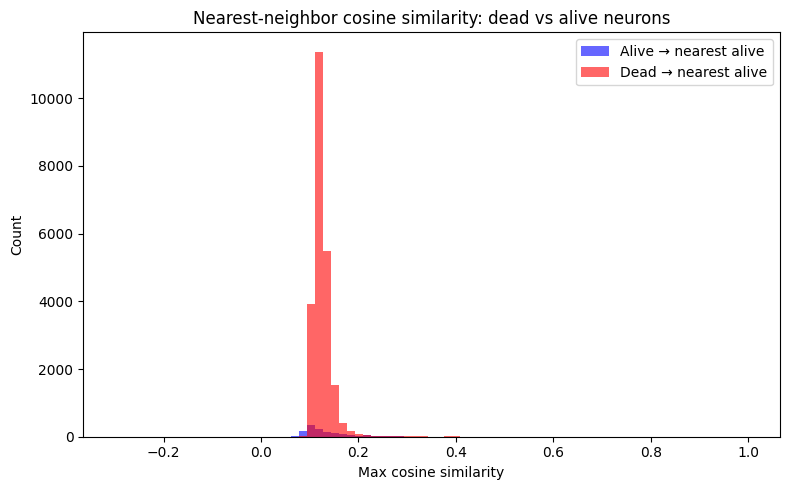

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(-0.3, 1.0, 80)
ax.hist(nn_alive_vals, bins=bins, alpha=0.6, label='Alive → nearest alive', color='blue')
ax.hist(nn_dead_vals,  bins=bins, alpha=0.6, label='Dead → nearest alive',  color='red')
ax.set_xlabel('Max cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Nearest-neighbor cosine similarity: dead vs alive neurons')
ax.legend()
plt.tight_layout()
plt.show()

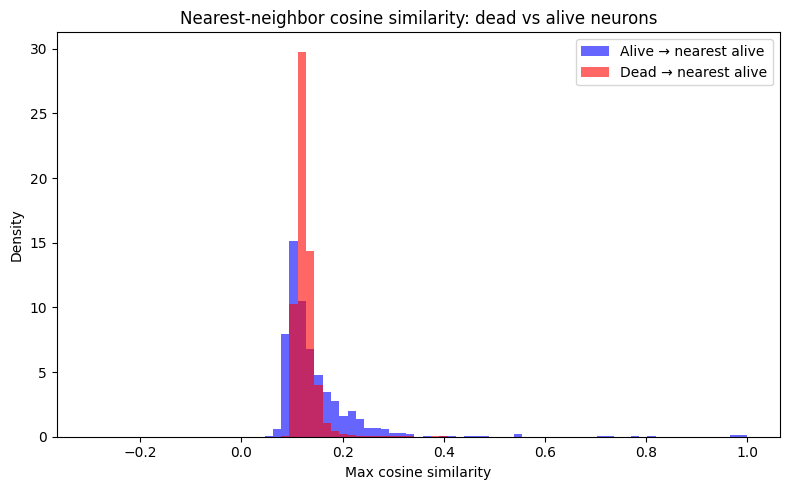

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(-0.3, 1.0, 80)
ax.hist(nn_alive_vals, bins=bins, alpha=0.6, label='Alive → nearest alive', color='blue', density=True)
ax.hist(nn_dead_vals,  bins=bins, alpha=0.6, label='Dead → nearest alive',  color='red',  density=True)
ax.set_xlabel('Max cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Nearest-neighbor cosine similarity: dead vs alive neurons')
ax.legend()
plt.tight_layout()
plt.show()


In [20]:
duplicate_threshold = 0.8
duplicate_idxs = (cosine_similarities_alive_alive.max(dim=1).values > duplicate_threshold).nonzero().squeeze()
print(f"Alive neurons with a near-duplicate: {len(duplicate_idxs)}")
print(f"Alive neurons with a near-duplicate: {len(duplicate_idxs)} ({100 * len(duplicate_idxs) / len(alive_neuron_idxs):.1f}% of alive)")

Alive neurons with a near-duplicate: 8
Alive neurons with a near-duplicate: 8 (0.6% of alive)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: adityaiyer-m (adityaiyer-m-self) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


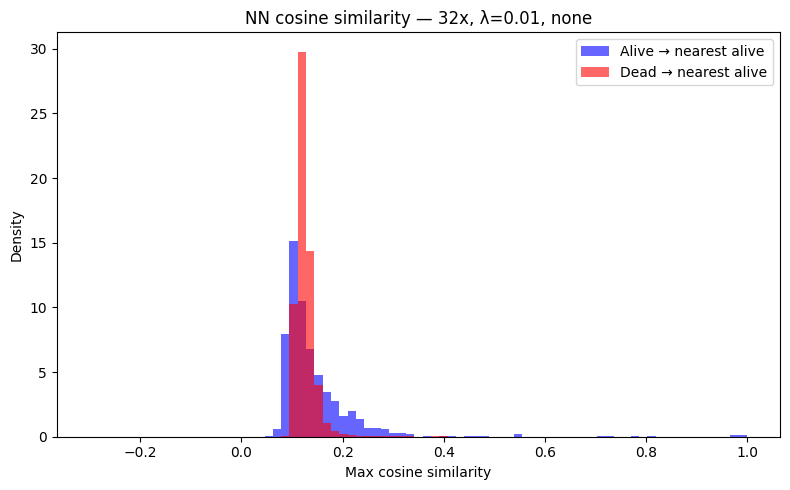

cosine/alive_alive/max,▁
cosine/alive_alive/mean,▁
cosine/alive_alive/median,▁
cosine/alive_alive/std,▁
cosine/dead_alive/max,▁
cosine/dead_alive/mean,▁
cosine/dead_alive/median,▁
cosine/dead_alive/std,▁
dead_neuron/alive_count,▁
dead_neuron/count,▁
+1,...


In [21]:
sampling_strategy = "none"  # e.g. "random", "topk", "neuron_resample"

# --- derived stats ---
total_neurons    = expansion_factor * model_dim
n_dead           = len(dead_neurons_idxs)
n_alive          = len(alive_neuron_idxs)
dead_proportion  = n_dead / total_neurons

dead_alive_stats = {
    "cosine/dead_alive/mean":   float(nn_dead_vals.mean()),
    "cosine/dead_alive/median": float(np.median(nn_dead_vals)),
    "cosine/dead_alive/std":    float(nn_dead_vals.std()),
    "cosine/dead_alive/max":    float(nn_dead_vals.max()),
}
alive_alive_stats = {
    "cosine/alive_alive/mean":   float(nn_alive_vals.mean()),
    "cosine/alive_alive/median": float(np.median(nn_alive_vals)),
    "cosine/alive_alive/std":    float(nn_alive_vals.std()),
    "cosine/alive_alive/max":    float(nn_alive_vals.max()),
}

# --- histogram figure ---
fig_wandb, ax_wandb = plt.subplots(figsize=(8, 5))
bins = np.linspace(-0.3, 1.0, 80)
ax_wandb.hist(nn_alive_vals, bins=bins, alpha=0.6, label='Alive → nearest alive', color='blue', density=True)
ax_wandb.hist(nn_dead_vals,  bins=bins, alpha=0.6, label='Dead → nearest alive',  color='red',  density=True)
ax_wandb.set_xlabel('Max cosine similarity')
ax_wandb.set_ylabel('Density')
ax_wandb.set_title(f'NN cosine similarity — {expansion_factor}x, λ={_lambda}, {sampling_strategy}')
ax_wandb.legend()
plt.tight_layout()

# --- wandb ---
wandb.init(
    project="sae-for-monosemanticity",
    name=f"dead_neuron_analysis_{expansion_factor}x_{sampling_strategy}_lambda{_lambda}",
    config={
        "expansion_factor":   expansion_factor,
        "model_dim":          model_dim,
        "lambda":             _lambda,
        "sampling_strategy":  sampling_strategy,
    }
)

wandb.log({
    "dead_neuron/count":       n_dead,
    "dead_neuron/proportion":  dead_proportion,
    "dead_neuron/alive_count": n_alive,
    **dead_alive_stats,
    **alive_alive_stats,
    "cosine/histogram":        wandb.Image(fig_wandb),
    "cosine/dead_alive_dist":  wandb.Histogram(nn_dead_vals),
    "cosine/alive_alive_dist": wandb.Histogram(nn_alive_vals),
})

plt.show()
wandb.finish()


## Sanity Check

In [22]:
w1 = torch.load(local_weights_dir / f"model_weights_{expansion_factor}x_0.01.pth", map_location="cpu")
w2 = torch.load(local_weights_dir / f"model_weights_{expansion_factor}x_0.0001.pth", map_location="cpu")
print(torch.equal(w1['W_enc'], w2['W_enc']))  # Should be False

False


In [23]:
# Check if the two feature tables in DuckDB are actually different
t1 = f"hf_{expansion_factor}x_0_01_full"
t2 = f"hf_{expansion_factor}x_0_0001_full"
con = feature_analyzer.con

count1 = con.execute(f"SELECT COUNT(*) FROM {t1}").fetchone()[0]
count2 = con.execute(f"SELECT COUNT(*) FROM {t2}").fetchone()[0]
print(f"{t1} rows: {count1}")
print(f"{t2} rows: {count2}")

# Compare a sample of actual activation values
sample1 = con.execute(f"SELECT feature_id, activation_value FROM {t1} ORDER BY feature_id, activation_value LIMIT 20").df()
sample2 = con.execute(f"SELECT feature_id, activation_value FROM {t2} ORDER BY feature_id, activation_value LIMIT 20").df()
print(f"\n{t1} sample:\n{sample1}")
print(f"\n{t2} sample:\n{sample2}")
print(f"\nSamples identical: {sample1.equals(sample2)}")

hf_32x_0_01_full rows: 173680200
hf_32x_0_0001_full rows: 173680200

hf_32x_0_01_full sample:
    feature_id  activation_value
0            7          2.831619
1            7          2.862620
2            7          2.862620
3            7          2.874949
4            7          2.890732
5            7          2.953008
6            7          3.006159
7            7          3.122391
8            7          3.131494
9            7          3.157675
10           7          3.164524
11           7          3.205446
12           7          3.209377
13           7          3.243590
14           7          3.258263
15           7          3.267957
16           7          3.277933
17           7          3.278616
18           7          3.299196
19           7          3.311564

hf_32x_0_0001_full sample:
    feature_id  activation_value
0            8          2.427572
1            8          2.453088
2            8          2.458052
3            8          2.468837
4            8      